In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
new_df = pd.read_csv('train.csv')

In [3]:
new_df.shape

(404290, 6)

In [4]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [5]:
# new_df = df.sample(30000,random_state=2)

In [6]:
new_df.isnull().sum()

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

In [7]:
new_df.dropna(inplace=True)


In [8]:
new_df.isnull().sum()

id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64

In [9]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [10]:
new_df.isnull().sum()

id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64

In [11]:
new_df.dropna(inplace = True)

In [12]:
new_df.isnull().sum()

id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64

In [13]:
new_df.duplicated().sum()

np.int64(0)

is_duplicate
0    255024
1    149263
Name: count, dtype: int64
is_duplicate
0    63.079941
1    36.920059
Name: count, dtype: float64


<Axes: xlabel='is_duplicate'>

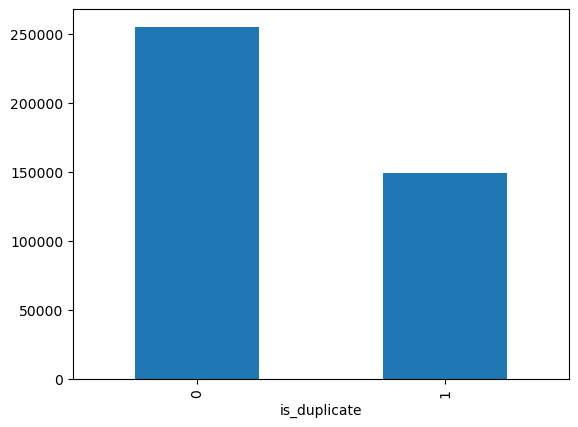

In [14]:
# Distribution of duplicate and non-duplicate questions

print(new_df['is_duplicate'].value_counts())
print((new_df['is_duplicate'].value_counts()/new_df['is_duplicate'].count())*100)
new_df['is_duplicate'].value_counts().plot(kind='bar')

In [15]:
# Repeated questions

qid = pd.Series(new_df['qid1'].tolist() + new_df['qid2'].tolist())
print('Number of unique questions',np.unique(qid).shape[0])
x = qid.value_counts()>1
print('Number of questions getting repeated',x[x].shape[0])

Number of unique questions 537929
Number of questions getting repeated 111778


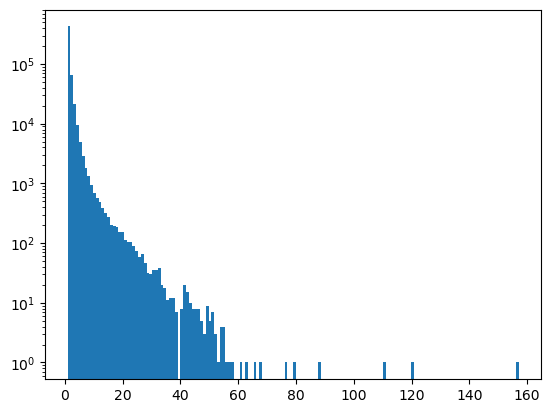

In [16]:
# Repeated questions histogram

plt.hist(qid.value_counts().values,bins=160)
plt.yscale('log')
plt.show()

In [17]:
# Feature Engineering

new_df['q1_len'] = new_df['question1'].str.len() 
new_df['q2_len'] = new_df['question2'].str.len()

In [18]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0,66,57
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0,51,88
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0,73,59
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0,50,65
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0,76,39


In [19]:
new_df['q1_num_words'] = new_df['question1'].apply(lambda row: len(row.split(" ")))
new_df['q2_num_words'] = new_df['question2'].apply(lambda row: len(row.split(" ")))
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0,66,57,14,12
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0,51,88,8,13
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0,73,59,14,10
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0,50,65,11,9
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0,76,39,13,7


In [20]:
def common_words(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split()))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split()))    
    return len(w1 & w2)

In [21]:
new_df['word_common'] = new_df.apply(common_words, axis=1)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0,66,57,14,12,10
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0,51,88,8,13,4
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0,73,59,14,10,4
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0,50,65,11,9,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0,76,39,13,7,2


In [22]:
def total_words(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))    
    return (len(w1) + len(w2))

In [23]:
new_df['word_total'] = new_df.apply(total_words, axis=1)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0,66,57,14,12,10,23
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0,51,88,8,13,4,20
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0,73,59,14,10,4,24
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0,50,65,11,9,0,19
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0,76,39,13,7,2,20


In [24]:
new_df['word_share'] = round(new_df['word_common']/new_df['word_total'],2)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0,66,57,14,12,10,23,0.43
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0,51,88,8,13,4,20,0.20
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0,73,59,14,10,4,24,0.17
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0,50,65,11,9,0,19,0.00
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0,76,39,13,7,2,20,0.10


minimum characters 1
maximum characters 623
average num of characters 59


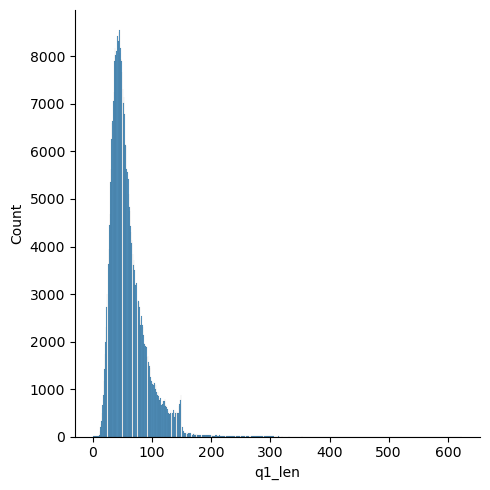

In [25]:
# Analysis of features
sns.displot(new_df['q1_len'])
print('minimum characters',new_df['q1_len'].min())
print('maximum characters',new_df['q1_len'].max())
print('average num of characters',int(new_df['q1_len'].mean()))

minimum characters 1
maximum characters 1169
average num of characters 60


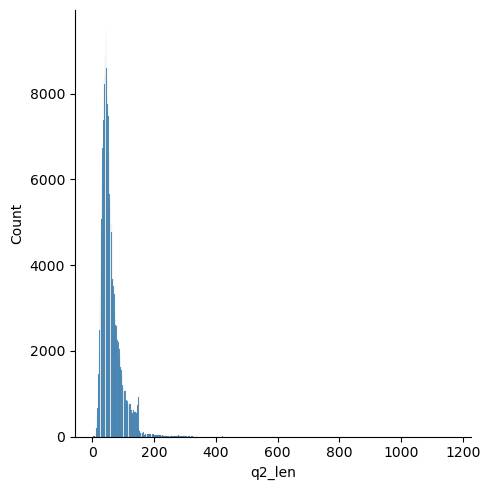

In [26]:
sns.displot(new_df['q2_len'])
print('minimum characters',new_df['q2_len'].min())
print('maximum characters',new_df['q2_len'].max())
print('average num of characters',int(new_df['q2_len'].mean()))

minimum words 1
maximum words 125
average num of words 10


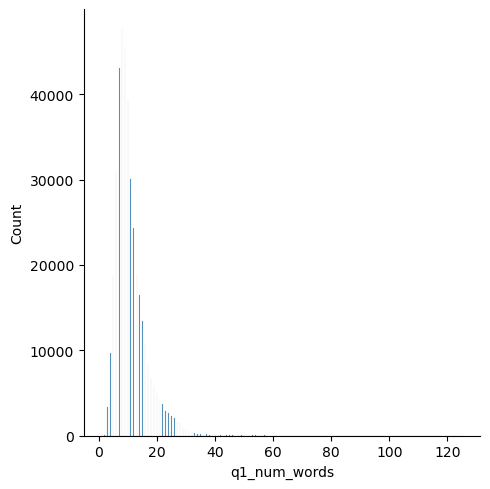

In [27]:
sns.displot(new_df['q1_num_words'])
print('minimum words',new_df['q1_num_words'].min())
print('maximum words',new_df['q1_num_words'].max())
print('average num of words',int(new_df['q1_num_words'].mean()))

minimum words 1
maximum words 237
average num of words 11


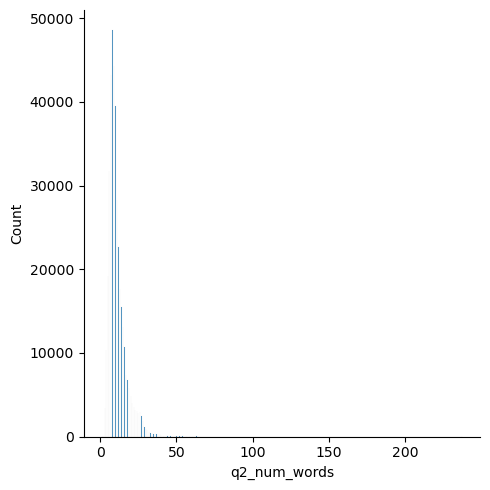

In [28]:
sns.displot(new_df['q2_num_words'])
print('minimum words',new_df['q2_num_words'].min())
print('maximum words',new_df['q2_num_words'].max())
print('average num of words',int(new_df['q2_num_words'].mean()))

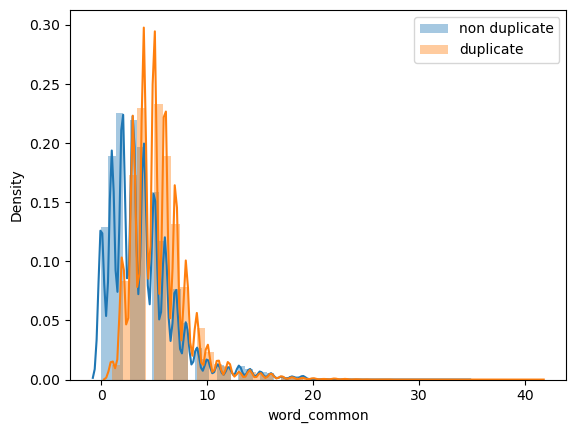

In [29]:
# common words
sns.distplot(new_df[new_df['is_duplicate'] == 0]['word_common'],label='non duplicate')
sns.distplot(new_df[new_df['is_duplicate'] == 1]['word_common'],label='duplicate')
plt.legend()
plt.show()

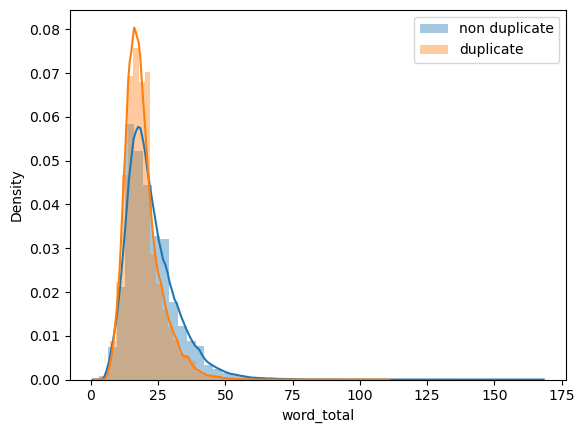

In [30]:
# total words
sns.distplot(new_df[new_df['is_duplicate'] == 0]['word_total'],label='non duplicate')
sns.distplot(new_df[new_df['is_duplicate'] == 1]['word_total'],label='duplicate')
plt.legend()
plt.show()

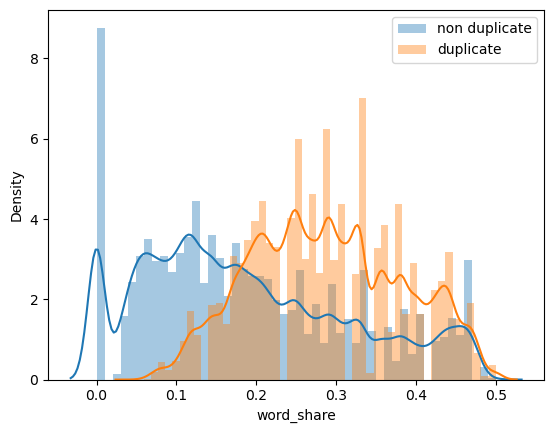

In [31]:
# word share
sns.distplot(new_df[new_df['is_duplicate'] == 0]['word_share'],label='non duplicate')
sns.distplot(new_df[new_df['is_duplicate'] == 1]['word_share'],label='duplicate')
plt.legend()
plt.show()

In [32]:
ques_df = new_df[['question1','question2']]
ques_df.head()

,question1,question2
0,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...
1,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...
2,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...
3,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...
4,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?


In [33]:
final_df = new_df.drop(columns=['id','qid1','qid2','question1','question2'])
print(final_df.shape)
final_df.head()

(404287, 8)


,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share
0,0,66,57,14,12,10,23,0.43
1,0,51,88,8,13,4,20,0.20
2,0,73,59,14,10,4,24,0.17
3,0,50,65,11,9,0,19,0.00
4,0,76,39,13,7,2,20,0.10


In [39]:
# pip install dask_ml

In [37]:
# pip install dask._task_spec

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement dask._task_spec (from versions: none)
ERROR: No matching distribution found for dask._task_spec


In [40]:
import dask.dataframe as dd
from dask_ml.feature_extraction.text import HashingVectorizer

# Convert to Dask DataFrame
ques_ddf = dd.from_pandas(ques_df, npartitions=10)

# Combine questions
questions = dd.concat([ques_ddf['question1'], ques_ddf['question2']])

# Use HashingVectorizer
hv = HashingVectorizer(n_features=3000)
sparse_matrix = hv.fit_transform(questions.compute())  # Compute before transformation

# Split the sparse matrix
q1_sparse = sparse_matrix[:len(ques_df)]
q2_sparse = sparse_matrix[len(ques_df):]


In [41]:
# from sklearn.feature_extraction.text import CountVectorizer
# # merge texts
# questions = list(ques_df['question1']) + list(ques_df['question2'])

# cv = CountVectorizer(max_features=3000)
# q1_arr, q2_arr = np.vsplit(cv.fit_transform(questions).toarray(),2)

In [42]:
# # ✅ Ensure q1_sparse & q2_sparse are NumPy arrays
# if not isinstance(q1_sparse, np.ndarray):
#     q1_sparse = q1_sparse.toarray()  # Convert sparse matrix to dense array

# if not isinstance(q2_sparse, np.ndarray):
#     q2_sparse = q2_sparse.toarray()

In [43]:

# import pandas as pd
# import dask.dataframe as dd

# temp_df1 = pd.DataFrame(q1_sparse, index=ques_df.index) 
# temp_df2 = pd.DataFrame(q2_sparse, index=ques_df.index)  
# temp_df1 = dd.from_pandas(temp_df1, npartitions=30)
# temp_df2 = dd.from_pandas(temp_df2, npartitions=30)

# temp_df = dd.concat([temp_df1, temp_df2], axis=1)

# result = temp_df.compute()


# print(result.shape)
# print(result.head())


In [44]:
import pandas as pd
import dask.dataframe as dd
import dask.delayed
import numpy as np
import os
from scipy.sparse import issparse

# Define chunk size (smaller)
CHUNK_SIZE = 100  

# Create temporary storage
TEMP_DIR = "temp_parquet"
os.makedirs(TEMP_DIR, exist_ok=True)

# Function to process sparse matrix row-wise and write to Parquet
def process_sparse_rows(sparse_matrix, start_idx, nrows=CHUNK_SIZE):
    end_idx = min(start_idx + nrows, sparse_matrix.shape[0])
    rows = sparse_matrix[start_idx:end_idx]

    if issparse(rows):  
        rows = rows.tocsr()  # Efficient format
        data = {f"col_{i}": rows[:, i].toarray().ravel() for i in range(rows.shape[1])}  
    else:
        data = rows  

    df = pd.DataFrame(data, dtype=np.float64)  # Use float64 for precision
    filename = f"{TEMP_DIR}/chunk_{start_idx}.parquet"
    df.to_parquet(filename)  # Write chunk to disk
    return filename  # Return file path

# Convert sparse matrices to delayed tasks (saving to disk)
delayed_files_q1 = [dask.delayed(process_sparse_rows)(q1_sparse, i, CHUNK_SIZE) 
                     for i in range(0, q1_sparse.shape[0], CHUNK_SIZE)]
delayed_files_q2 = [dask.delayed(process_sparse_rows)(q2_sparse, i, CHUNK_SIZE) 
                     for i in range(0, q2_sparse.shape[0], CHUNK_SIZE)]

# Convert delayed file paths into Dask DataFrames (reading from disk)
temp_df1 = dd.read_parquet(list(dask.compute(*delayed_files_q1)))
temp_df2 = dd.read_parquet(list(dask.compute(*delayed_files_q2)))

# Concatenate Dask DataFrames along columns
temp_df = dd.concat([temp_df1, temp_df2], axis=1)

# Optimize memory further by reducing partitions
temp_df = temp_df.repartition(npartitions=5)

# Compute and print first few rows efficiently
print(temp_df.head())

# Optional: Clean up temporary files
import shutil
shutil.rmtree(TEMP_DIR)


   col_0  col_1  col_2  col_3  col_4  col_5  col_6  col_7  col_8  col_9  ...  \
0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0  ...   
1    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0  ...   
2    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0  ...   
3    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0  ...   
4    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0  ...   

   col_2990  col_2991  col_2992  col_2993  col_2994  col_2995  col_2996  \
0       0.0       0.0       0.0       0.0       0.0       0.0       0.0   
1       0.0       0.0       0.0       0.0       0.0       0.0       0.0   
2       0.0       0.0       0.0       0.0       0.0       0.0       0.0   
3       0.0       0.0       0.0       0.0       0.0       0.0       0.0   
4       0.0       0.0       0.0       0.0       0.0       0.0       0.0   

   col_2997  col_2998  col_2999  
0       0.0       0.0       0.0  


In [45]:
# import dask.dataframe as dd

# temp_df1 = dd.from_pandas(temp_df1, npartitions=10)
# temp_df2 = dd.from_pandas(temp_df2, npartitions=10)
# temp_df = dd.concat([temp_df1, temp_df2], axis=1)
# result = temp_df.compute()  # Converts back to a Pandas DataFrame

In [46]:
# temp_df1 = pd.DataFrame(q1_arr, index= ques_df.index)
# temp_df2 = pd.DataFrame(q2_arr, index= ques_df.index)
# temp_df = pd.concat([temp_df1, temp_df2], axis=1)
# temp_df.shape

In [47]:
# final_df = pd.concat([final_df, temp_df], axis=1)
# print(final_df.shape)
# final_df.head()

In [48]:
# import pandas as pd

# # Define batch size to avoid excessive memory usage
# BATCH_SIZE = 5000  # Adjust based on available memory

# # Convert Dask DataFrame to Pandas DataFrame in smaller chunks
# final_df_list = []
# for batch in temp_df.to_delayed():  # Iterate through partitions
#     batch_pandas = batch.compute()  # Compute only a batch at a time
#     final_df_list.append(batch_pandas)  # Store in a list to minimize memory impact

# # Concatenate batches into a single Pandas DataFrame
# temp_df_pandas = pd.concat(final_df_list, axis=0)

# # Reset index to avoid duplicate index errors
# final_df = final_df.reset_index(drop=True)
# temp_df_pandas = temp_df_pandas.reset_index(drop=True)

# # Now, concatenate the DataFrames
# final_df = pd.concat([final_df, temp_df_pandas], axis=1)

# # Check shape and preview
# print(final_df.shape)
# print(final_df.head())


In [49]:
# C:\Users\updes\Duplicate question pairs-Latwst - working model\temp_chunks

In [ ]:
import pandas as pd
import dask.dataframe as dd
import dask.delayed
import numpy as np
import os
from scipy.sparse import issparse

# Define chunk size (smaller)
CHUNK_SIZE = 100  

# Create temporary storage
TEMP_DIR = r"C:\Users\updes\Duplicate question pairs-Latwst - working model\temp_chunks"
os.makedirs(TEMP_DIR, exist_ok=True)

# Function to process sparse matrix row-wise and write to Parquet
def process_sparse_rows(sparse_matrix, start_idx, nrows=CHUNK_SIZE):
    end_idx = min(start_idx + nrows, sparse_matrix.shape[0])
    rows = sparse_matrix[start_idx:end_idx]

    if issparse(rows):  
        rows = rows.tocsr()  # Efficient format
        data = {f"col_{i}": rows[:, i].toarray().ravel() for i in range(rows.shape[1])}  
    else:
        data = rows  

    df = pd.DataFrame(data, dtype=np.float64)  # Use float64 for precision
    filename = f"{TEMP_DIR}/chunk_{start_idx}.parquet"
    df.to_parquet(filename)  # Write chunk to disk
    return filename  # Return file path

# Convert sparse matrices to delayed tasks (saving to disk)
delayed_files_q1 = [dask.delayed(process_sparse_rows)(q1_sparse, i, CHUNK_SIZE) 
                     for i in range(0, q1_sparse.shape[0], CHUNK_SIZE)]
delayed_files_q2 = [dask.delayed(process_sparse_rows)(q2_sparse, i, CHUNK_SIZE) 
                     for i in range(0, q2_sparse.shape[0], CHUNK_SIZE)]

# Convert delayed file paths into Dask DataFrames (reading from disk)
temp_df1 = dd.read_parquet(list(dask.compute(*delayed_files_q1)))
temp_df2 = dd.read_parquet(list(dask.compute(*delayed_files_q2)))

# Concatenate Dask DataFrames along columns
temp_df = dd.concat([temp_df1, temp_df2], axis=1)

# Optimize memory further by reducing partitions
temp_df = temp_df.repartition(npartitions=5)

# Compute and print first few rows efficiently
print(temp_df.head())

# Optional: Clean up temporary files
import shutil
shutil.rmtree(TEMP_DIR)


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(final_df.iloc[:,1:].values,final_df.iloc[:,0].values,test_size=0.2,random_state=1)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)

In [ ]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train,y_train)
y_pred = xgb.predict(X_test)
accuracy_score(y_test,y_pred)

## Advanced Features

### 1. Token Features
- **cwc_min**: This is the ratio of the number of common words to the length of the smaller question
- **cwc_max**: This is the ratio of the number of common words to the length of the larger question
- **csc_min**: This is the ratio of the number of common stop words to the smaller stop word count among the two questions
- **csc_max**: This is the ratio of the number of common stop words to the larger stop word count among the two questions
- **ctc_min**: This is the ratio of the number of common tokens to the smaller token count among the two questions
- **ctc_max**: This is the ratio of the number of common tokens to the larger token count among the two questions
- **last_word_eq**: 1 if the last word in the two questions is same, 0 otherwise
- **first_word_eq**: 1 if the first word in the two questions is same, 0 otherwise

### 2. Length Based Features
- **mean_len**: Mean of the length of the two questions (number of words)
- **abs_len_diff**: Absolute difference between the length of the two questions (number of words)
- **longest_substr_ratio**: Ratio of the length of the longest substring among the two questions to the length of the smaller question

### 3. Fuzzy Features
- **fuzz_ratio**: fuzz_ratio score from fuzzywuzzy
- **fuzz_partial_ratio**: fuzz_partial_ratio from fuzzywuzzy
- **token_sort_ratio**: token_sort_ratio from fuzzywuzzy
- **token_set_ratio**: token_set_ratio from fuzzywuzzy